# 02 — A hybrid neural density model with a smooth scale nuisance

We now build the **good fitted model**, before deliberately introducing misspecification in notebook 03. There is no event selection. The five reconstructed observables $x=(x_1,\ldots,x_5)$ enter the density networks; physical parameters enter the likelihood later.

The reference design is the same as Exercise 5: an equally weighted nominal signal/background mixture, learned by a normalized flow $p_{\mathrm{ref}}(x)$. Its 50:50 training composition is a numerical choice. The experiment still has $S=100$ and $B=1\,000$ at $\mu=1$.

We train nominal process/reference ratios and up/down process/nominal ratios, normalize the resulting six complete anchors, and use **normalized polynomial–exponential interpolation**. Its nuisance-dependent normalization is part of the likelihood and its gradient. The interpolation is smooth through the nominal nuisance value.

Run notebook 01 first. The nominal-ratio pool now contains 10 million events per class; network architectures and ensemble sizes are unchanged. Full training requires a GPU and substantial memory; this notebook does not claim good training until the held-out diagnostics below have been inspected.
**Fresh training run:** this version defaults to `DIAGNOSTICS_ONLY = False`. Run notebook 01, then restart the runtime and use **Run all** here. The new shared TAG preserves the previous run. Section 7 runs the member-level diagnostics after training. To inspect already completed models later, set `DIAGNOSTICS_ONLY = True`; missing checkpoints then raise an error rather than starting training.


## Setup and shared run directory

Run this cell first. Use the same `RUN_NAME` in all five notebooks. Colab can keep the run on Drive; locally, open Jupyter in this directory. Use a fresh kernel when switching from the older exercises. Training and samples remain in the run directory.


In [1]:
# Run this cell first in each notebook. All five notebooks share RUN_NAME.
import os
import sys
import subprocess
from pathlib import Path

TAG = "sb10_exppoly_10m_slowlr_v3_20261001"  # Fresh run: 10M nominal-ratio events per class and gradual LR decay.
RUN_NAME = TAG
USE_DRIVE = True
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO = Path("/content/nsbi_calibration_toolkit")
    BRANCH = "ml4hep_school_tutorial"
    if not (REPO / ".git").exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH,
            "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git", str(REPO),
        ], check=True, env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"})
        subprocess.run([
            "git", "-C", str(REPO), "sparse-checkout", "set", "src",
            "workshops/ml4hep_tifr_colab/calibration",
        ], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only", "origin", BRANCH], check=True)
    SOURCE = REPO / "workshops/ml4hep_tifr_colab/calibration"
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "-r",
        str(SOURCE / "requirements.txt"),
    ], check=True)
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        RUN_BASE = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs")
    else:
        RUN_BASE = Path("/content/calibration_runs")
else:
    # Open the notebook with calibration/ as its working directory.
    SOURCE = Path.cwd().resolve()
    REPO = SOURCE.parents[2]
    RUN_BASE = SOURCE / "runs"

sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(SOURCE))
os.chdir(SOURCE)
RUN = Path(os.environ.get("CALIBRATION_RUN", RUN_BASE / RUN_NAME)).resolve()
RUN.mkdir(parents=True, exist_ok=True)
print("Source:", SOURCE)
print("TAG:", TAG)
print("Run:", RUN)
if "CALIBRATION_RUN" in os.environ:
    print("CALIBRATION_RUN overrides the tagged path; verify that it points to the intended run.")
print("Use a fresh kernel when switching between the old exercises and calibration.")


Mounted at /content/drive
Source: /content/nsbi_calibration_toolkit/workshops/ml4hep_tifr_colab/calibration
TAG: sb10_exppoly_10m_slowlr_v3_20261001
Run: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001
Use a fresh kernel when switching between the old exercises and calibration.


In [2]:

# True: load saved models and run section 7 only; never train or renormalize.
DIAGNOSTICS_ONLY = False

import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from model import FEATURES, load_config, save_config, morph, nll, fit, asimov_weights
from sampling import read_sample, sample_process
from flow_reference import train_reference, MODEL_DEFAULTS, TRAIN_DEFAULTS
from utils import (HybridModel, RatioEnsemble, train_ratio, save_hybrid,
                   plot_ratio_diagnostics, plot_shape_closure, RATIO_DEFAULTS)

config = load_config(RUN)
SEED = config['seed'] + 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HYBRID = RUN / 'hybrid'
PLOTS = HYBRID / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
print('Device:', DEVICE)
print('Sample configuration:', config['samples'])
print('Mode:', 'saved-model ratio diagnostics only' if DIAGNOSTICS_ONLY else 'full notebook')


Device: cuda
Sample configuration: {'flow_train_per_process': 500000, 'nominal_ratio_per_class': 10000000, 'evaluation_per_process': 250000, 'variation_ratio_per_class': 1000000}
Mode: full notebook


## 1. Fix the sample budgets and the model definitions

| Stage | Input sample size | Network |
|---|---:|---|
| Reference flow | 500,000 nominal events per process | 10 spline coupling layers, 16 bins, tail bound 5; 4-block networks of width 1024 |
| Nominal signal/reference and background/reference ratios | 10,000,000 events per class | Four independently initialized members, 4 hidden layers of width 1024 |
| Each up/down to nominal deformation ratio | 1,000,000 events per class | One network, 4 hidden layers of width 1024 |
| Anchor normalization | 5,000,000 fresh reference-flow events | No training |
| External diagnostics | Up to 250,000 independent events per process/anchor | No training or tuning |

The first three sizes come from notebook 01's configuration, so a reduced run remains internally consistent. The flow and nominal ratio training partitions are disjoint. Scale variations share latent events with their nominal partners; the final diagnostics use an entirely separate row block. For the deformation classifiers we use the first 1,000,000 varied rows and the last 1,000,000 nominal ratio-training rows, so paired latent events do not straddle their internal splits at the default sizes. The final, disjoint diagnostic block remains the decisive validation.

`REUSE=True` reloads a stage already trained in this run. Use a **new run name** when changing samples, architecture, or training settings; this keeps the next notebooks tied to one concrete density model.

All six ratio estimators use 150 epochs, with the learning rate halved every 10 epochs from $10^{-3}$. Epochs 1, 41, 81, 121, and 141 begin at approximately $10^{-3}$, $6.25\times10^{-5}$, $3.91\times10^{-6}$, $2.44\times10^{-7}$, and $6.10\times10^{-8}$. Early-stopping patience is separately set to 150 epochs so it cannot terminate this schedule prematurely. The saved network is still the checkpoint with the lowest validation loss, which may precede the last epoch. Flow training keeps its existing schedule. Sample counts are input pools before the train/validation/holdout splits.


In [3]:
if not DIAGNOSTICS_ONLY:
    REUSE = True
    N_REFERENCE_INTEGRATION = 5_000_000
    N_DIAGNOSTIC_REFERENCE = 250_000
    NOMINAL_ENSEMBLE = 4
    FLOW_MODEL = dict(MODEL_DEFAULTS)
    FLOW_TRAINING = dict(TRAIN_DEFAULTS)
    RATIO_TRAINING = dict(RATIO_DEFAULTS)

    settings = dict(reference_integration=N_REFERENCE_INTEGRATION,
                    diagnostic_reference=N_DIAGNOSTIC_REFERENCE,
                    nominal_ensemble=NOMINAL_ENSEMBLE,
                    flow_model=FLOW_MODEL, flow_training=FLOW_TRAINING,
                    ratio_training=RATIO_TRAINING)
    (HYBRID / 'training_settings.json').write_text(json.dumps(settings, indent=2))

## 2. Learn a reusable reference density

Train the flow by maximum likelihood on the balanced nominal sample:

$$\mathcal L_{\mathrm{flow}}=-\frac{1}{M}\sum_{j=1}^{M}\log p_{\mathrm{ref},\phi}(x_j).$$

The standardization is fitted on the flow's optimization split, and its Jacobian is included in `log_prob`. The flow's exact normalization comes from its invertible construction. Agreement with the desired mixture must still be checked on independent data.

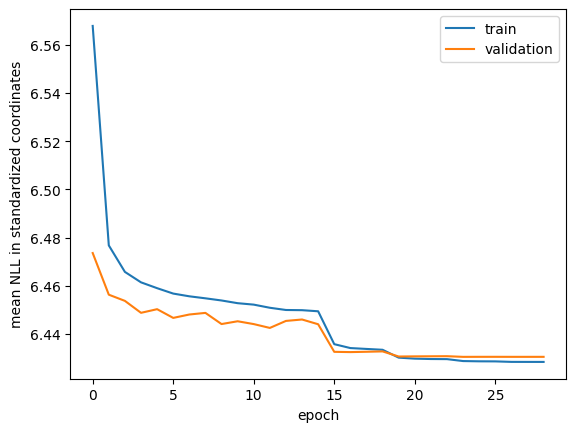

In [4]:
if not DIAGNOSTICS_ONLY:
    flow_training_x = np.concatenate([
        read_sample(RUN, process, partition='flow_train')
        for process in ['signal', 'background']])
    reference_flow = train_reference(
        flow_training_x, HYBRID / 'reference.pt', model_config=FLOW_MODEL,
        training_config=FLOW_TRAINING, device=DEVICE, seed=SEED, reuse=REUSE)
    del flow_training_x
    gc.collect()

    saved_flow = torch.load(HYBRID / 'reference.pt', map_location='cpu', weights_only=False)
    history = np.asarray(saved_flow['history'])
    plt.plot(history[:, 0], label='train')
    plt.plot(history[:, 1], label='validation')
    plt.xlabel('epoch'); plt.ylabel('mean NLL in standardized coordinates'); plt.legend()
    plt.savefig(PLOTS / 'flow_loss.png', bbox_inches='tight')
    plt.show()
    del saved_flow

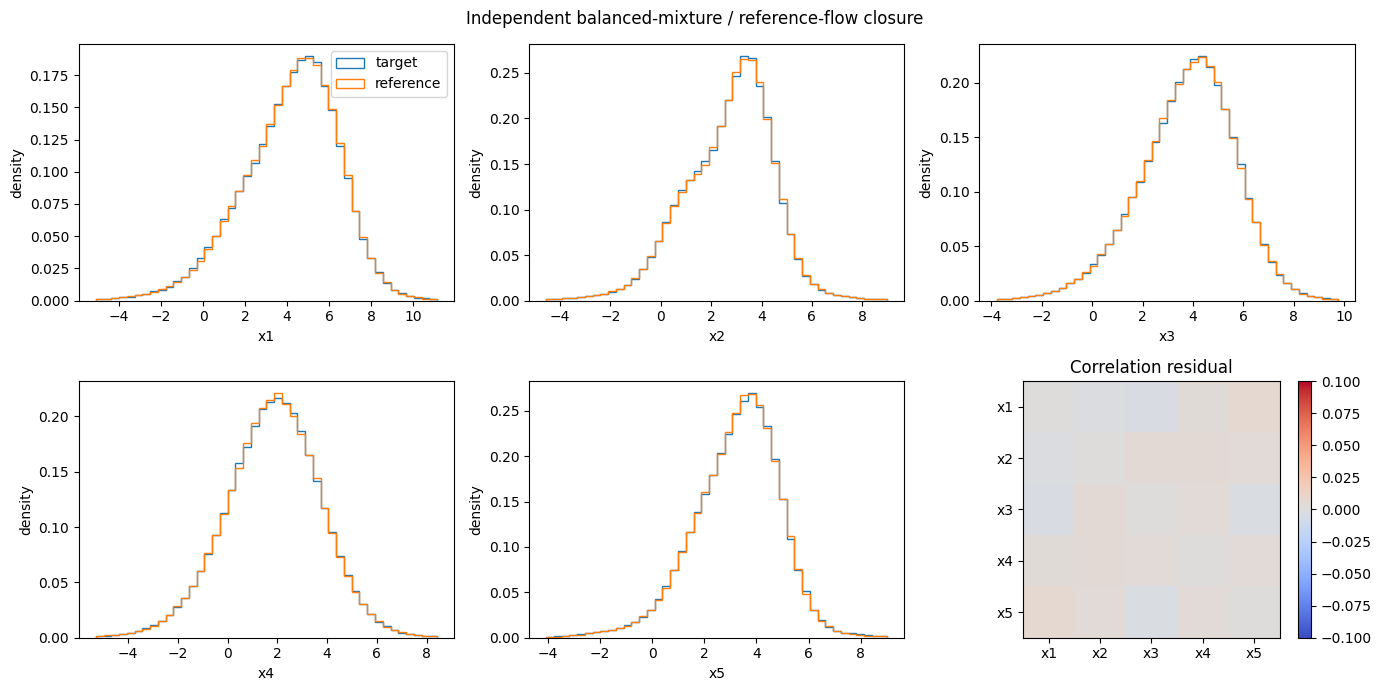

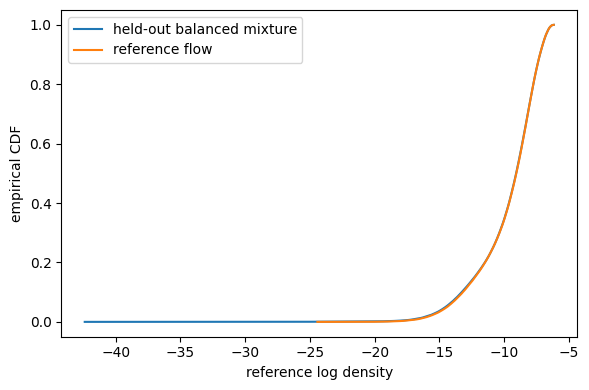

In [5]:
if not DIAGNOSTICS_ONLY:
    flow_target = np.concatenate([
        read_sample(RUN, process, partition='eval', n=min(125_000, config['samples']['evaluation_per_process']))
        for process in ['signal', 'background']])
    flow_diagnostic_x = reference_flow.sample(N_DIAGNOSTIC_REFERENCE, SEED + 1)
    fig = plot_shape_closure(flow_target, flow_diagnostic_x,
                             title='Independent balanced-mixture / reference-flow closure')
    fig.savefig(PLOTS / 'flow_shape_closure.png', bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    for x, label in [(flow_target, 'held-out balanced mixture'),
                     (flow_diagnostic_x, 'reference flow')]:
        logp = np.sort(reference_flow.log_prob(x))
        ax.plot(logp, np.arange(1, len(logp) + 1) / len(logp), label=label)
    ax.set(xlabel='reference log density', ylabel='empirical CDF')
    ax.legend(); fig.tight_layout()
    fig.savefig(PLOTS / 'flow_log_density_cdf.png')
    plt.show()
    del flow_target

## 3. Train the nominal process/reference ratios

A classifier with equally normalized class weights minimizes binary cross entropy. Its optimal logit is

$$\ell_c(x)=\log\frac{p_c(x)}{p_{\mathrm{ref}}(x)},\qquad r_c(x)=\exp\ell_c(x).$$

We use the existing `nsbi_common_utils` trainer, with its logit-output option. This is the same classification objective, and avoids converting a numerically saturated sigmoid back into a ratio. `utils.py` returns the arithmetic mean of the four member **ratios**, as in the earlier exercises.

The flow-generated denominator below is used only for ratio training. Neither the normalization bank nor the independent diagnostic reference sample is taken from it. The external reliability plot tests the actual ensemble prediction; the reweighting plots test whether denominator events weighted by the predicted ratio reproduce the target.

2026-10-02 22:42:28 | INFO | Training Logs | Reading saved models from /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/signal/
INFO:Training Logs:Reading saved models from /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/signal/
2026-10-02 22:42:49 | WARNING | Training Logs | signal training data has max score = 1, which may indicate numerical instability!
2026-10-02 22:42:49 | WARNING | Training Logs | signal holdout data has max score = 1, which may indicate numerical instability!
2026-10-02 22:43:00 | INFO | Training Logs | Reading saved models from /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/signal/
INFO:Training Logs:Reading saved models from /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hyb

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693174 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.632357 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.704309 | val_loss = 0.631815 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.631990 | val_loss = 0.631468 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.631787 | val_loss = 0.631482 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.631712 | val_loss = 0.631584 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.631656 | val_loss = 0.631461 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.631577 | val_loss = 0.631351 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.631488 | val_loss = 0.631327 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.631418 | val_loss = 0.631408 | 
Epoch    9 | lr = 5.000e-04 | train_loss = 0.631375 | val_loss = 0.631248 | 
Epoch   10 | lr = 5.000e-04 | train_loss = 0.631321 | val_loss = 0.631024 | 
Epoch   11 | lr = 5.000e-04 | train_loss = 0.631044 | val_loss = 0.630983 | 
Epoch   12 | lr = 5.000e-04 | train_loss = 0.63

...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


2026-10-03 16:22:50 | WARNING | Training Logs | signal training data has max score = 1, which may indicate numerical instability!
2026-10-03 16:22:50 | WARNING | Training Logs | signal holdout data has max score = 1, which may indicate numerical instability!


<Figure size 800x600 with 0 Axes>

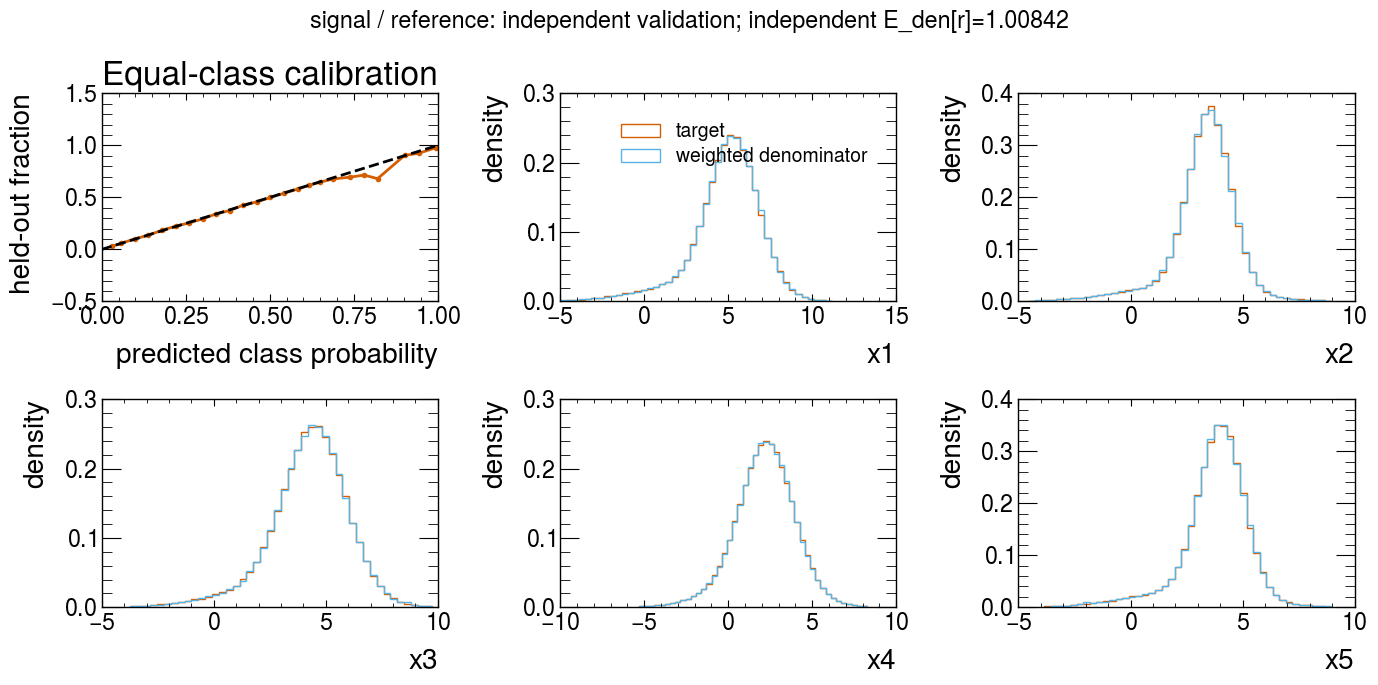

2026-10-03 16:22:59 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/background/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/background/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/background/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/background/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/ratios/background/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693222 | 


/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.652151 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.653492 | val_loss = 0.651614 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.651568 | val_loss = 0.651626 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.651427 | val_loss = 0.651660 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.651319 | val_loss = 0.652130 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.651223 | val_loss = 0.651886 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.651151 | val_loss = 0.651086 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.651090 | val_loss = 0.651060 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.651054 | val_loss = 0.651213 | 
Epoch    9 | lr = 5.000e-04 | train_loss = 0.651015 | val_loss = 0.651662 | 
Epoch   10 | lr = 5.000e-04 | train_loss = 0.653027 | val_loss = 0.650967 | 
Epoch   11 | lr = 5.000e-04 | train_loss = 0.650834 | val_loss = 0.650963 | 
Epoch   12 | lr = 5.000e-04 | train_loss = 0.650735 | val_loss = 0.650930 | 
Epoch   13 | lr = 5.000

In [ ]:
if not DIAGNOSTICS_ONLY:
    n_ratio = config['samples']['nominal_ratio_per_class']
    reference_ratio_training = reference_flow.sample(n_ratio, SEED + 2)
    ratio_models = {}
    for i, process in enumerate(['signal', 'background']):
        target = read_sample(RUN, process, partition='ratio_train', n=n_ratio)
        ratio_models[process] = train_ratio(
            target, reference_ratio_training, HYBRID / 'ratios' / process,
            members=NOMINAL_ENSEMBLE, seed=SEED + 100 + 10 * i,
            settings=RATIO_TRAINING, reuse=REUSE)
        heldout = read_sample(RUN, process, partition='eval')
        fig = plot_ratio_diagnostics(ratio_models[process], heldout, flow_diagnostic_x,
                                     title=f'{process} / reference: independent validation')
        fig.savefig(PLOTS / f'ratio_{process}.png', bbox_inches='tight')
        plt.show()
        del target, heldout
        gc.collect()
    del reference_ratio_training

## 4. Learn the scale-deformation ratios

For each process we train two more classifiers,

$$d_c^\pm(x)=\frac{p_c^{\pm}(x)}{p_c^0(x)}.$$

Their inputs are again the five reconstructed variables; neither $\mu$ nor $\alpha$ enters these fixed-anchor classifiers. The complete raw reference-relative anchors are

$$\widetilde R_c^0=r_c,\qquad \widetilde R_c^- = r_c d_c^-,\qquad \widetilde R_c^+=r_c d_c^+.$$

The deformation ratios are not interpolated in log space. We first construct and normalize these **complete process/reference anchors**, and only then interpolate. We also validate the complete products below: separately good nominal and deformation plots do not by themselves establish good hNDE closure.

In [ ]:
if not DIAGNOSTICS_ONLY:
    n_variation = config['samples']['variation_ratio_per_class']
    for i, process in enumerate(['signal', 'background']):
        # Different latent rows from the varied numerator, whose first rows are used.
        nominal = read_sample(RUN, process, partition='ratio_train')[-n_variation:].copy()
        nominal_eval = read_sample(RUN, process, partition='eval')
        for j, direction in enumerate(['down', 'up']):
            name = f'{process}_{direction}'
            varied = read_sample(RUN, process, partition='ratio_train',
                                 anchor=direction, n=n_variation)
            ratio_models[name] = train_ratio(
                varied, nominal, HYBRID / 'ratios' / name,
                members=1, seed=SEED + 200 + 10 * i + j,
                settings=RATIO_TRAINING, reuse=REUSE)
            varied_eval = read_sample(RUN, process, partition='eval', anchor=direction)
            fig = plot_ratio_diagnostics(ratio_models[name], varied_eval, nominal_eval,
                                         title=f'{process}: {direction} / nominal')
            fig.savefig(PLOTS / f'ratio_{name}.png', bbox_inches='tight')
            plt.show()
            del varied, varied_eval
            gc.collect()
        del nominal, nominal_eval

## 5. Normalize the complete nuisance-dependent densities

Draw a fresh integration bank $X_j\sim p_{\mathrm{ref}}$ and normalize each complete anchor:

$$Z_c^k=M^{-1}\sum_j\widetilde R_c^k(X_j),\qquad
R_c^k(x)=\widetilde R_c^k(x)/Z_c^k,\quad k\in\{-,0,+\}.$$

The six saved anchors have unit mean on this bank. For intermediate nuisance values, use the paper's sixth-degree polynomial $v_c(x;\alpha)$, smoothly matched to exponential extrapolation at $\pm1$. Unlike the old linear mixture, this polynomial does not preserve the anchor normalization automatically:

$$R_c(x;\alpha)=\frac{R_c^0(x)v_c(x;\alpha)}{Z_c(\alpha)},\qquad
Z_c(\alpha)=M^{-1}\sum_j R_c^0(X_j)v_c(X_j;\alpha).$$

The denominator is differentiated in every fit and neural loss. Its polynomial coefficients are precomputed on the integration bank. This gives exact normalization on that finite bank, not exact continuous normalization; an independent bank checks the remaining integration error.

Positive anchors do not guarantee a positive polynomial between them. Only for an event/process whose polynomial fails the positivity check, we add $\lambda(x)\alpha^2(1-\alpha^2)^3$. This nonnegative term preserves all three anchors, the nominal first derivative, and the value/first/second derivatives at the outer joins. The resulting degree-eight coefficients remain precomputable. The diagnostics report the affected fraction and added mass; no negative-density clipping is hidden in the likelihood. Fits remain inside $[-1,1]$ and expected yields remain $\nu S$ and $B$.


In [ ]:
if not DIAGNOSTICS_ONLY:
    if REUSE and (HYBRID / 'manifest.json').exists():
        hybrid = HybridModel.load(RUN, DEVICE)
    else:
        hybrid = HybridModel(RUN, reference_flow, ratio_models)
        manifest = save_hybrid(hybrid, n_reference=N_REFERENCE_INTEGRATION, seed=SEED + 3)
        print('Saved hybrid model:', manifest['model_id'])

    config = hybrid.configure(config)
    save_config(config, RUN)
    integration_anchors = hybrid.reference_anchors()
    from interpolation import numpy_coefficients
    # Reuse these coefficients across all full-bank Asimov queries.
    integration_coefficients = numpy_coefficients(integration_anchors)
    print('Raw anchor normalizations, rows S/B and columns down/nominal/up:')
    print(hybrid.normalization)
    print('Integration-bank normalized means:')
    print(np.mean(integration_anchors, axis=0))
    print('Model ID:', hybrid.model_id)

In [ ]:
if not DIAGNOSTICS_ONLY:
    # Independent of training AND of the bank used to estimate Z.
    check_x = hybrid.sample_reference(N_DIAGNOSTIC_REFERENCE, SEED + 4)
    check_anchors = hybrid.anchors(check_x)
    rows = []
    for c, process in enumerate(['signal', 'background']):
        for k, direction in enumerate(['down', 'nominal', 'up']):
            r = check_anchors[:, c, k]
            mean, se = r.mean(), r.std(ddof=1) / np.sqrt(len(r))
            rows.append(dict(process=process, anchor=direction, mean=mean,
                             standard_error=se, residual=mean - 1,
                             residual_over_check_SE=(mean - 1) / se,
                             effective_sample_size=r.sum()**2 / np.square(r).sum()))
    closure = pd.DataFrame(rows)
    closure.to_csv(HYBRID / 'independent_normalization_closure.csv', index=False)
    display(closure)

    for c, process in enumerate(['signal', 'background']):
        for k, direction in enumerate(['down', 'nominal', 'up']):
            target = read_sample(RUN, process, partition='eval', anchor=direction)
            fig = plot_shape_closure(target, check_x, weights=check_anchors[:, c, k],
                                     title=f'Complete {process} {direction} hNDE: held-out closure')
            fig.savefig(PLOTS / f'complete_{process}_{direction}.png', bbox_inches='tight')
            plt.show()
            del target

### Check the complete interpolation and its nominal derivative

The independent normalization curve includes every nuisance value, not just the anchors. Its error band is conditional on the saved integration bank. The positivity table reports how many event/process polynomials need the sparse correction and the largest fraction of normalization it adds. A large correction would mean the anchor interpolation itself deserves reconsideration.

The derivative plot compares the new normalized morph with the previous linear interpolation for illustrative events selected to show a visible kink near $\alpha=0$. This illustrates smoothness; the subsequent likelihood and Asimov checks assess its inference consequences.


In [ ]:
if not DIAGNOSTICS_ONLY:
    from diagnostics import (interpolation_diagnostics, physical_population_closure,
                             plot_population_closure)

    print("Integration-bank positivity diagnostics:")
    display(pd.DataFrame({key: value for key, value in hybrid.morph_diagnostics.items()
                          if isinstance(value, list)}))
    fig, derivative_fig, morph_table, repair_table = interpolation_diagnostics(check_anchors, config)
    display(repair_table)
    morph_table.to_csv(HYBRID / 'interpolation_closure.csv', index=False)
    repair_table.to_csv(HYBRID / 'positivity_repair.csv', index=False)
    fig.savefig(PLOTS / 'interpolation_closure.png', dpi=150)
    derivative_fig.savefig(PLOTS / 'nominal_morph_derivative.png', dpi=150)
    plt.show()


### Intermediate detector-scale closure

The physical simulator uses the continuous response mean $(1+0.1\alpha)s_jz_j$. The fitted model interpolates three learned anchors. These are different constructions between the anchors, so the plots at $\alpha=\pm0.5$ test both learned-density and interpolation error. Reference-model toys use the fitted normalized exp-poly density instead. Nominal physical response and calibration toys still have $\alpha_{\rm gen}=0$.


In [ ]:
if not DIAGNOSTICS_ONLY:
    for alpha in (-.5, .5):
        shaped = morph(check_anchors, alpha, config)
        for process_index, process in enumerate(('signal', 'background')):
            rng = np.random.default_rng(SEED + 60 + process_index + int(10 * (alpha + 1)))
            target = sample_process(process, min(100_000, len(check_x)), rng, alpha=alpha)
            fig = plot_shape_closure(target, check_x, weights=shaped[:, process_index],
                                     title=f'{process}: continuous simulator vs exp-poly, alpha={alpha:+.1f}')
            fig.savefig(PLOTS / f'intermediate_{process}_{alpha:+.1f}.png', bbox_inches='tight')
            plt.show()


The reported standard error is the fresh check-bank uncertainty **conditional on the saved normalization constants**. Their own Monte Carlo uncertainty is additional. A large residual or a low effective sample size calls for a larger integration/check bank and another independent check; with $B=1\,000$, small relative normalization errors can matter in a fit.

The projected plots and correlation residuals are useful diagnostics, not a mathematical guarantee of full five-dimensional agreement. The next notebooks include unbinned inference checks using fresh physical simulator events, which can reveal errors these plots miss.

## 6. Reference-sampled, weighted unbinned Asimov fits

The extended likelihood, after omitting parameter-independent reference-density factors, is

$$\log L_H(\nu,\alpha;D,y)=-\nu S-B
 +\sum_{x\in D}\log[\nu S R_S(x;\alpha)+B R_B(x;\alpha)]
 -\frac{(y-\alpha)^2}{2}.$$

For a model-closure Asimov experiment at $(\mu_A,\alpha_A)$, reuse the normalized integration bank with weights

$$w_j=\frac{\mu_A S R_S(X_j;\alpha_A)+B R_B(X_j;\alpha_A)}{M},
\qquad y_A=\alpha_A.$$

These weights sum to the expected count. They replace the event sum in the NLL; there is no binning. We minimize over both $\nu$ and $\alpha$. `fit` uses analytic gradients of the normalized smooth likelihood, several starting points, and explicit boundary checks. Its success flag includes a projected-gradient check.

These are **internal closure tests of the good fitted model**, so the fitted parameters should recover the generating values up to optimizer precision. They do not measure model bias on the physical simulator. In later population-response training, the required auxiliary ensemble is $y\sim\mathrm{Uniform}[-2,2]$, whose expected Gaussian-constraint term has the same parameter dependence as $y=0$. Here $y_A=\alpha_A$ is chosen specifically to test model closure at nonzero anchors.

In [ ]:
if not DIAGNOSTICS_ONLY:
    asimov_rows = []
    for mu_A, alpha_A in [(0.5, -0.5), (1.0, 0.0), (1.5, 0.5)]:
        weights = asimov_weights(integration_anchors, mu_A, alpha_A, config, coefficients=integration_coefficients)
        result = fit(integration_anchors, auxiliary=alpha_A, config=config, weights=weights, coefficients=integration_coefficients)
        asimov_rows.append(dict(mu_A=mu_A, alpha_A=alpha_A,
                                expected_count=mu_A * config['signal_yield'] + config['background_yield'],
                                weight_sum=weights.sum(), fitted_nu=result['nu'],
                                fitted_alpha=result['alpha'], success=result['success']))
    asimov_results = pd.DataFrame(asimov_rows)
    asimov_results.to_csv(HYBRID / 'asimov_closure.csv', index=False)
    display(asimov_results)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    for ax, truth, fitted in [(axes[0], 'mu_A', 'fitted_nu'),
                              (axes[1], 'alpha_A', 'fitted_alpha')]:
        ax.scatter(asimov_results[truth], asimov_results[fitted], label='unbinned Asimov fit')
        limits = [asimov_results[truth].min() - .1, asimov_results[truth].max() + .1]
        ax.plot(limits, limits, 'k--', label='closure')
        ax.set(xlabel=truth, ylabel=fitted)
        ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS / 'asimov_parameter_closure.png')
    plt.show()
    # Full-bank coefficients are no longer needed by the remaining diagnostics.
    del integration_coefficients
    gc.collect()


### Physical population closure before adding deliberate misspecification

Internal Asimov closure is necessary but does not establish agreement with the physical simulator. We therefore fit fresh nominal physical population samples with $\epsilon=0$ at three signal strengths. Three independent banks reveal how much the result moves with Monte Carlo integration. The bank spread is a diagnostic, not a confidence interval. A persistent common displacement calls for revisiting density training or normalization before blaming the response network.


In [ ]:
if not DIAGNOSTICS_ONLY:
    good_physical_closure = physical_population_closure(
        hybrid, config, n_per_process=100_000, n_banks=3,
        mu_grid=(.5, 1., 1.5), seed=SEED + 70)
    display(good_physical_closure)
    good_physical_closure.to_csv(HYBRID / 'epsilon_zero_physical_closure.csv', index=False)
    fig = plot_population_closure(good_physical_closure)
    fig.savefig(PLOTS / 'epsilon_zero_physical_closure.png', dpi=150)
    plt.show()


## 7. Inspect the frozen ratio members without retraining

This section loads the saved flow and ONNX ratio members directly. It uses **new, independently simulated numerator and denominator events**, including for the up/down comparisons: the two classes do not share latent events. All members of a given ratio see exactly the same events. No member is selected, recalibrated, retrained, or removed, and the arithmetic **mean of ratios** is the existing ensemble definition.

The simulator has a known Gaussian-mixture density, so this demonstration has an additional diagnostic oracle:

$$\log r_c^{\rm exact}(x)=\log p_c^{\rm sim}(x;0)-\log p_{\rm ref}(x),\qquad
\log d_c^{\pm,\rm exact}(x)=\log p_c^{\rm sim}(x;\pm1)-\log p_c^{\rm sim}(x;0).$$

The nominal denominator is the **actual saved flow**, not the ideal balanced mixture. Log densities are evaluated directly, without flooring small densities. The exact curves therefore test the ratios that the classifiers were trained to estimate. These are raw classifier-ratio diagnostics, before complete-anchor normalization and nuisance interpolation.

For each ratio we display:

- Each member, the ensemble, and the exact-ratio benchmark on reliability/residual plots, using common uniform bins and common equal-occupancy bins. The bin counts and approximate 95% Wilson intervals make sparse tails visible. These are pointwise intervals for balanced independent classes, not simultaneous bands or training uncertainty; the fixed class totals make the binomial interpretation approximate.
- Numerator and denominator occupancy, including zero-count classes, with full numeric bin tables saved alongside the plots.
- Log-ratio errors relative to the oracle, using common exact-score bins, and a table of balanced cross-entropy, paired excess-loss uncertainty, normalization, effective sample size, log-ratio error, and high-score event fractions.

`Member 1` corresponds to `model0.onnx`, and so on. One-member systematic estimators have the same member and ensemble prediction. The table keeps this ordering; it is not a model ranking. These samples are for diagnosis and possible development decisions. If we subsequently tune or select models using them, final validation must use another independent sample.


In [ ]:
from flow_reference import ReferenceFlow
from sampling import process_log_density
from ratio_diagnostics import diagnostic_report

# Increase this later if the occupancy plots show that tail statistics are limiting.
N_RATIO_DIAGNOSTIC_PER_CLASS = min(250_000, config['samples']['evaluation_per_process'])
RATIO_DIAGNOSTIC_SEED = SEED + 1_000_000
RATIO_DIAGNOSTIC_DIR = HYBRID / 'ratio_diagnostics'

ratio_cases = [
    ('signal', 'signal', 0., 'reference'),
    ('background', 'background', 0., 'reference'),
    ('signal_down', 'signal', -1., 'nominal'),
    ('signal_up', 'signal', 1., 'nominal'),
    ('background_down', 'background', -1., 'nominal'),
    ('background_up', 'background', 1., 'nominal'),
]

# Preflight every network before sampling. There is deliberately no train fallback.
required = [HYBRID / 'reference.pt']
ratio_metadata = {}
for name, _, _, _ in ratio_cases:
    directory = HYBRID / 'ratios' / name
    manifest_path = directory / 'ensemble.json'
    required.append(manifest_path)
    if manifest_path.is_file():
        metadata = json.loads(manifest_path.read_text())
        members = metadata.get('members')
        if not isinstance(members, int) or isinstance(members, bool) or members < 1:
            raise ValueError(f'Invalid member count in {manifest_path}')
        ratio_metadata[name] = metadata
        for member in range(members):
            required.extend([directory / f'model{member}.onnx',
                             directory / f'model_scaler{member}.bin'])
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'Saved-model diagnostics require the completed notebook-02 run. '
        'Check Drive and the existing TAG/RUN path; no training was started. '
        'Missing files:\n' + '\n'.join(missing))
if N_RATIO_DIAGNOSTIC_PER_CLASS < 2:
    raise ValueError('At least two diagnostic events per class are required.')

RATIO_DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)
diagnostic_flow = ReferenceFlow.load(HYBRID / 'reference.pt', DEVICE)
reference_check = diagnostic_flow.sample(
    N_RATIO_DIAGNOSTIC_PER_CLASS, RATIO_DIAGNOSTIC_SEED)
reference_logq = diagnostic_flow.log_prob(reference_check).astype(np.float64)
print('Loaded existing flow; no training or normalization will be performed.')
print('Fresh independent events per class:', N_RATIO_DIAGNOSTIC_PER_CLASS)
print('Saved members:', {name: meta['members'] for name, meta in ratio_metadata.items()})
print('Diagnostic output:', RATIO_DIAGNOSTIC_DIR)


In [ ]:
summary_tables, bin_tables = [], []
for case_index, (name, process, alpha, denominator_kind) in enumerate(ratio_cases):
    numerator_seed = RATIO_DIAGNOSTIC_SEED + 10 + 2 * case_index
    denominator_seed = numerator_seed + 1
    numerator = sample_process(process, N_RATIO_DIAGNOSTIC_PER_CLASS,
                               np.random.default_rng(numerator_seed), alpha=alpha)
    if denominator_kind == 'reference':
        denominator = reference_check
        log_den_num = diagnostic_flow.log_prob(numerator).astype(np.float64)
        log_den_den = reference_logq
        title = f'{process} / saved reference flow'
    else:
        denominator = sample_process(process, N_RATIO_DIAGNOSTIC_PER_CLASS,
                                     np.random.default_rng(denominator_seed), alpha=0.)
        log_den_num = process_log_density(numerator, process, alpha=0.)
        log_den_den = process_log_density(denominator, process, alpha=0.)
        title = f'{process}: alpha={alpha:+.0f} / nominal'

    exact_num = process_log_density(numerator, process, alpha=alpha) - log_den_num
    exact_den = process_log_density(denominator, process, alpha=alpha) - log_den_den
    saved_ratio = RatioEnsemble.load(HYBRID / 'ratios' / name, device=DEVICE)
    report = diagnostic_report(
        saved_ratio.member_log_ratios(numerator),
        saved_ratio.member_log_ratios(denominator),
        exact_num, exact_den, title=title)

    summary = report['summary'].assign(ratio=name)
    bins = report['bins'].assign(ratio=name)
    summary_tables.append(summary)
    bin_tables.append(bins)
    summary.to_csv(RATIO_DIAGNOSTIC_DIR / f'{name}_summary.csv', index=False)
    bins.to_csv(RATIO_DIAGNOSTIC_DIR / f'{name}_bins.csv', index=False)
    print('\n' + title)
    with pd.option_context('display.max_columns', None, 'display.precision', 6):
        display(summary[['model', 'bce', 'bce_excess_exact', 'bce_excess_exact_se',
                         'mean_ratio_den', 'mean_ratio_den_se', 'ess_fraction_den']].rename(
            columns={'model': 'Model', 'bce': 'BCE', 'bce_excess_exact': 'BCE - exact',
                     'bce_excess_exact_se': 'SE(BCE - exact)', 'mean_ratio_den': 'E_den[r]',
                     'mean_ratio_den_se': 'SE(E_den[r])', 'ess_fraction_den': 'ESS / N_den'}))
        display(summary[['model', 'tail_score_gt_075_num', 'tail_score_gt_075_den',
                         'tail_score_gt_090_num', 'tail_score_gt_090_den']].rename(
            columns={'model': 'Model', 'tail_score_gt_075_num': 'Num fraction s > 0.75',
                     'tail_score_gt_075_den': 'Den fraction s > 0.75',
                     'tail_score_gt_090_num': 'Num fraction s > 0.90',
                     'tail_score_gt_090_den': 'Den fraction s > 0.90'}))
    for figure_name, fig in report['figures']:
        fig.savefig(RATIO_DIAGNOSTIC_DIR / f'{name}_{figure_name}.png',
                    dpi=150, bbox_inches='tight')
        display(fig)
        plt.close(fig)
    del saved_ratio, numerator, denominator, report, exact_num, exact_den
    gc.collect()

ratio_summary = pd.concat(summary_tables, ignore_index=True)
ratio_bins = pd.concat(bin_tables, ignore_index=True)
ratio_summary.to_csv(RATIO_DIAGNOSTIC_DIR / 'all_ratio_summary.csv', index=False)
ratio_bins.to_csv(RATIO_DIAGNOSTIC_DIR / 'all_ratio_bins.csv', index=False)
model_manifest = HYBRID / 'manifest.json'
diagnostic_settings = dict(
    run=str(RUN), tag=TAG,
    model_id=json.loads(model_manifest.read_text()).get('model_id')
             if model_manifest.is_file() else None,
    n_per_class=N_RATIO_DIAGNOSTIC_PER_CLASS, seed=RATIO_DIAGNOSTIC_SEED,
    numerator_seed_rule='seed + 10 + 2*case_index; denominator seed is numerator seed + 1',
    cases=ratio_cases, ensemble_metadata=ratio_metadata,
    ensemble_definition='arithmetic mean of raw ratios',
    uncertainty='pointwise approximate Wilson 95% intervals; paired within-class BCE excess SE; CSV also has class-stratified residual delta SE',
    evaluation='fresh independent classes; diagnostic development sample, not model selection',
)
(RATIO_DIAGNOSTIC_DIR / 'diagnostic_settings.json').write_text(
    json.dumps(diagnostic_settings, indent=2))
del diagnostic_flow, reference_check, reference_logq
gc.collect()
print('Saved all member, ensemble, and exact-ratio diagnostics. Models are unchanged.')


## What is passed to notebook 03?

`hybrid/` contains the learned reference flow, six ratio estimators (the two nominal estimators are four-member ensembles), six anchor normalization constants, the nuisance-normalization coefficients, and the reference integration bank. `manifest.json` records their model identity. The next notebook changes one explicit mixture parameter $\epsilon$ while keeping this learned model fixed.

Reference-distribution toys are generated by importance resampling from flow proposals. A shared finite bank makes training practical, but it is an approximation to the continuous hNDE distribution. The helper returns the proposal size and effective sample size; fresh proposal banks and fresh physical toys are used to study this approximation separately. The auxiliary observable in all toys is drawn uniformly from $[-2,2]$, as requested, while the likelihood constraint remains Gaussian.